In [10]:
import sys
from pathlib import Path
import h5py

PROJECT_ROOT = Path.cwd().parents[1]   # move up from notebooks/
sys.path.insert(0, str(PROJECT_ROOT))
from proteins.data.bt import find_similar_sequences, align_sequences, ProteinAnalysis
from proteins.data.embed import ESMCForgeEmbedder

lcspik = 'MKVTGIFLLSALALLSLSGNTGADSLGREAKCYNELNGCTKIYDPVCGTDGNTYPNECVLCFENRKRQTSILIQKSGPC'
pros = 'MGKKSSHHHHHHSSKKGLVPRGSKVTGIFLLSALALLSLSGNTGADSLGREAKCYNELNGCTKIYDPVCGTDGNTYPNECVLCFENRKRQTSILIQKSGPC'
spink = 'GLVPRGSHMGSDSLGREAKCYNELNGCTKIYDPVCGTDGNTYPNECVLCFENRKRQTSILIQKSGPC'

data_dir = Path.cwd().parents[0] / 'data' / 'data_files' / 'lcs'
print(data_dir)

/Users/connorott/PycharmProjects/bioml/proteins/data/data_files/lcs


In [11]:
embedder = ESMCForgeEmbedder(model_name='esmc_300m', save_dir=data_dir, hidden=True)
embedder.batch_save({'lcspik': lcspik, 'pros': pros, 'spink': spink})

embedder = ESMCForgeEmbedder(model_name='esmc_600m', save_dir=data_dir, hidden=True)
embedder.batch_save({'lcspik': lcspik, 'pros': pros, 'spink': spink})

In [3]:
def get_h5_data(path, force=False):
    data = {}
    def visitor(name, node):
        if isinstance(node, h5py.Dataset):
            data[name] = node[()]  # load dataset into memory
    with h5py.File(path, "r") as f:
        n_stored_ids = len(set(f.keys()))
        if n_stored_ids > 30 and not force:
            raise RuntimeError(f"Found {n_stored_ids} stored IDs. {n_stored_ids} stored ids can cause memory issues. Set force to True if you want to load the data anyways.")
        f.visititems(visitor)
    return data

In [4]:
esm300 = get_h5_data(data_dir / 'esmc_300m_embeddings.h5')
esm600 = get_h5_data(data_dir / 'esmc_600m_embeddings.h5')


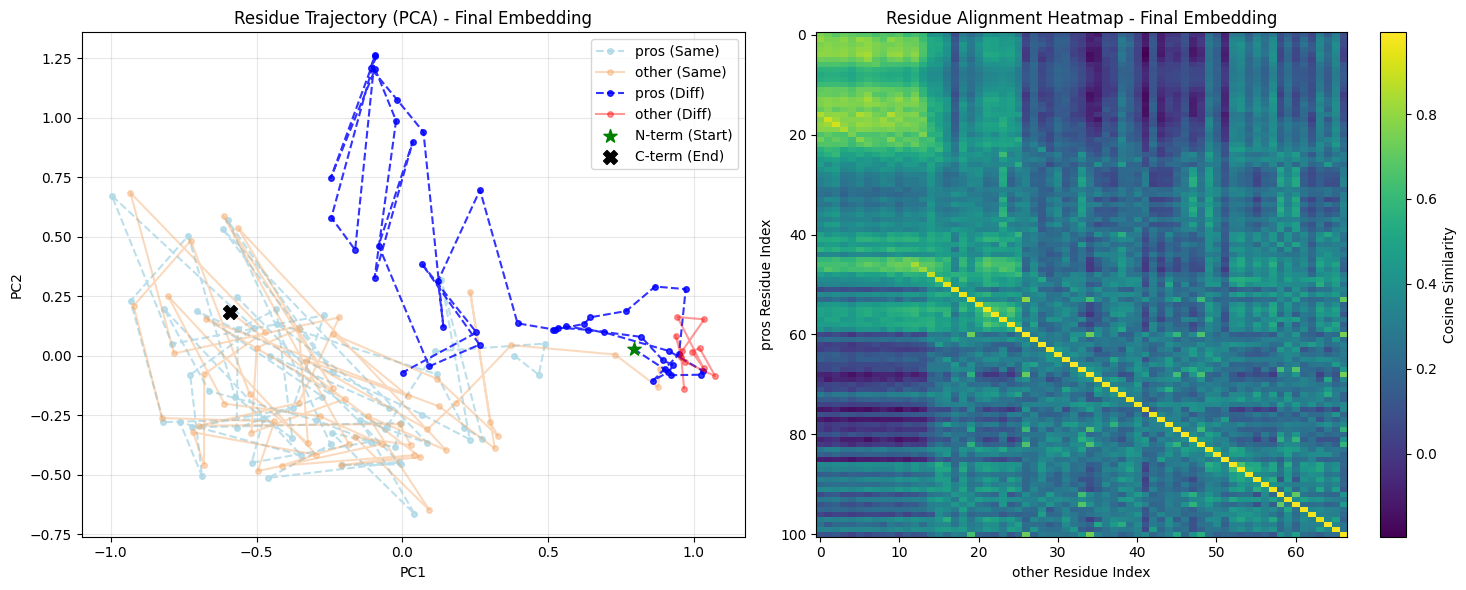

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

data_dict = esm600
ids = ['other','pros']
layer_idx=None

id1, id2 = 'pros', 'other'


if layer_idx is not None:
    # Shape: (n_layers, len, m_dim) -> Select specific layer -> (len, m_dim)
    feat1 = data_dict[f"{id1}_hidden"][layer_idx]
    feat2 = data_dict[f"{id2}_hidden"][layer_idx]
    title_suffix = f"Layer {layer_idx}"
else:
    # Shape: (len, m_dim)
    feat1 = data_dict[id1]
    feat2 = data_dict[id2]
    title_suffix = "Final Embedding"

# 2. PCA Trajectory reduction to 2D
combined_feats = np.concatenate([feat1, feat2], axis=0)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(combined_feats)

# Split back
len1 = feat1.shape[0]
proj1 = pca_result[:len1]
proj2 = pca_result[len1:]

proj1_same = proj1[45:]
proj2_same = proj2[11:]
proj1_diff = proj1[:45]
proj2_diff = proj2[:11]

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)

plt.plot(proj1_same[:, 0], proj1_same[:, 1], 'o--', color='lightblue', alpha=0.8, label=f'{id1} (Same)', markersize=4)
plt.plot(proj2_same[:, 0], proj2_same[:, 1], 'o-', color='sandybrown', alpha=0.4, label=f'{id2} (Same)', markersize=4)

plt.plot(proj1_diff[:, 0], proj1_diff[:, 1], 'o--', color='blue', alpha=0.8, label=f'{id1} (Diff)', markersize=4)
plt.plot(proj2_diff[:, 0], proj2_diff[:, 1], 'o-', color='red', alpha=0.4, label=f'{id2} (Diff)', markersize=4)


plt.scatter(proj1[0, 0], proj1[0, 1], c='green', s=100, marker='*', label='N-term (Start)', zorder=10)
plt.scatter(proj2[-1, 0], proj2[-1, 1], c='black', s=100, marker='X', label='C-term (End)', zorder=10)

plt.title(f"Residue Trajectory (PCA) - {title_suffix}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)

# --- Plot 2: Cosine Similarity Heatmap ---
plt.subplot(1, 2, 2)

# Compute similarity between every residue in P1 vs P2
# Matrix shape: (len1, len2)
sim_matrix = cosine_similarity(feat1, feat2)

plt.imshow(sim_matrix, aspect='auto', cmap='viridis', origin='upper')
plt.colorbar(label='Cosine Similarity')
plt.title(f"Residue Alignment Heatmap - {title_suffix}")
plt.xlabel(f"{id2} Residue Index")
plt.ylabel(f"{id1} Residue Index")

plt.tight_layout()